In [2]:
#General imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#astropy imports
import astropy.cosmology as Cosmology
from astropy import units as u 
from astropy import constants as const
from astropy.coordinates import SkyCoord

#Own-code imports
from GOALS_dataframe.analytic_neutrino_flux import *
from Diffuse_IceCube.diffuse_IceCube_plot import *



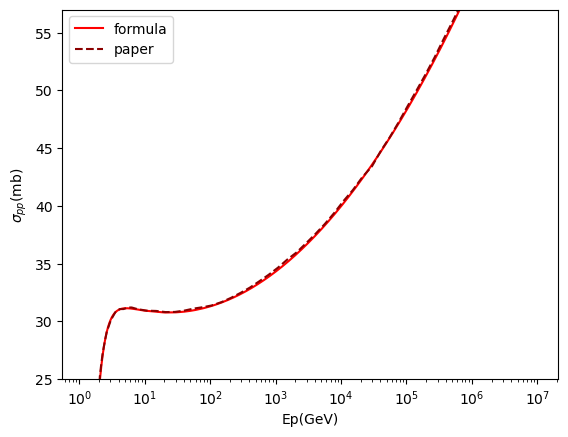

In [2]:
datacrosssection=pd.read_csv('Dataset_Figure_11.csv',sep=';', header=None, names=['X','Y'])
datacrosssection.X=datacrosssection.X.replace(',','.',regex=True)
datacrosssection.Y=datacrosssection.Y.replace(',','.',regex=True)
Xcs=datacrosssection.X.astype('float64')
Ycs=datacrosssection.Y.astype('float64')

Energy=np.linspace(1.22,10,1000000)
Energy=np.delete(Energy,10)
Energy=np.append(Energy,np.linspace(10,1e6,100000))

sigmapp=cross_section(Energy)
plt.plot(Energy,sigmapp,color='red',label='formula')
plt.plot(Xcs,Ycs,color='darkred',linestyle='--',label='paper')
plt.xscale('log')
plt.ylim(25,57)
plt.xlabel("Ep(GeV)")
plt.ylabel("$\sigma_{pp}$(mb)")
plt.legend()


/home/vcourvoi/Stage/neutrino-gamma-flux-GOALS-galaxies/GOALS_dataframe/analytic_neutrino_flux.py:175: RuntimeWarning: divide by zero encountered in scalar divide
  third = ( 1/np.log(x) ) - \
/home/vcourvoi/Stage/neutrino-gamma-flux-GOALS-galaxies/GOALS_dataframe/analytic_neutrino_flux.py:176: RuntimeWarning: divide by zero encountered in scalar divide
  ((4 * betagamma * x**betagamma) / (1 - x**betagamma)) - \
/home/vcourvoi/Stage/neutrino-gamma-flux-GOALS-galaxies/GOALS_dataframe/analytic_neutrino_flux.py:175: RuntimeWarning: invalid value encountered in scalar subtract
  third = ( 1/np.log(x) ) - \


0.002898927441133771


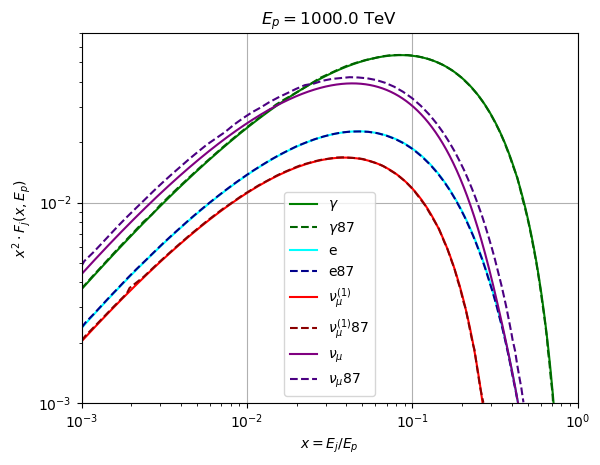

In [3]:
datanumu = pd.read_csv('Figure10/DatasetFigure10-1000TeV_numu.csv',sep=';', header=None, names=['X','Y'])
datanumu1 = pd.read_csv('Figure10/DatasetFigure10-1000TeV_numu1.csv',sep=';', header=None, names=['X','Y'])
datae = pd.read_csv('Figure10/DatasetFigure10-1000TeV_e.csv',sep=';', header=None, names=['X','Y'])
datagamma = pd.read_csv('Figure10/DatasetFigure10-1000TeV_gamma.csv',sep=';', header=None, names=['X','Y'])
tabdata=[datanumu,datanumu1,datae,datagamma]

for i in range(len(tabdata)):
    
    tabdata[i].X=tabdata[i].X.replace(',','.',regex=True)
    tabdata[i].Y=tabdata[i].Y.replace(',','.',regex=True)
    
Xnumu=datanumu.X.astype('float64')
Ynumu=datanumu.Y.astype('float64')
Xnumu1=datanumu1.X.astype('float64')
Ynumu1=datanumu1.Y.astype('float64')
Xe=datae.X.astype('float64')
Ye=datae.Y.astype('float64')
Xgamma=datagamma.X.astype('float64')
Ygamma=datagamma.Y.astype('float64')


#Ep=1e2
Ep=1e6
Egamma=np.linspace(Ep*1e-3,Ep,100000)
x=Egamma/Ep
x2Fgamma= x**2*Fgamma(x,Ep)
x2Fe = x**2*Fe(x,Ep)
x2Fmu1 = x**2*Fmu1(x,Ep)

x2Fmu=x**2*(Fmu1(x,Ep)+Fe(x,Ep))



diff=max(Ynumu)-max(x2Fmu)
print(diff)

plt.plot(x,x2Fgamma, label='$\gamma$',color='green')
plt.plot(Xgamma,Ygamma, label='$\gamma 87$',color='darkgreen',linestyle='--')


plt.plot(x,x2Fe,label='e',color='cyan')
plt.plot(Xe,Ye,label='e87',color='darkblue',linestyle='--')

plt.plot(x,x2Fmu1,label=r'$\nu_\mu^{(1)}$', color='red')
plt.plot(Xnumu1,Ynumu1,label=r'$\nu_\mu^{(1)}87$',linestyle='--',color='darkred')

plt.plot(x,x2Fmu,label=r'$\nu_\mu$',color='purple')
plt.plot(Xnumu,Ynumu,label=r'$\nu_\mu 87$',linestyle='--',color='indigo')

plt.xscale('log') ; plt.yscale('log')
plt.xlim(1e-3,1) ; plt.ylim(1e-3,7e-2)
plt.xlabel('$x=E_j/E_p$') ; plt.ylabel('$x^2 \cdot F_j (x,E_p)$')
plt.title('$E_p=$' + str(Ep/1000)+ ' TeV')


plt.grid()
plt.legend()




/home/vcourvoi/Stage/neutrino-gamma-flux-GOALS-galaxies/GOALS_dataframe/analytic_neutrino_flux.py:175: RuntimeWarning: divide by zero encountered in scalar divide
  third = ( 1/np.log(x) ) - \
/home/vcourvoi/Stage/neutrino-gamma-flux-GOALS-galaxies/GOALS_dataframe/analytic_neutrino_flux.py:176: RuntimeWarning: divide by zero encountered in scalar divide
  ((4 * betagamma * x**betagamma) / (1 - x**betagamma)) - \
/home/vcourvoi/Stage/neutrino-gamma-flux-GOALS-galaxies/GOALS_dataframe/analytic_neutrino_flux.py:175: RuntimeWarning: invalid value encountered in scalar subtract
  third = ( 1/np.log(x) ) - \


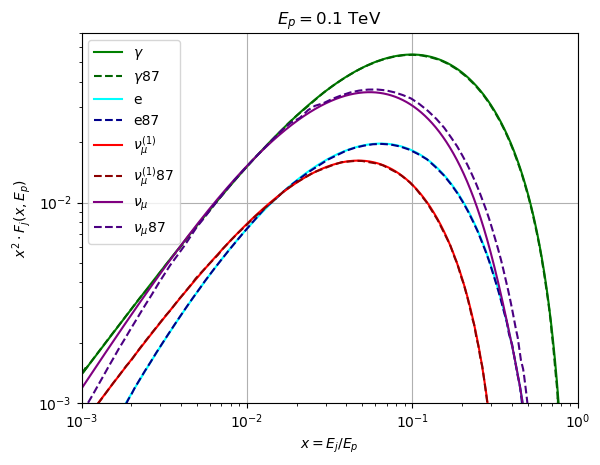

In [4]:
datanumu = pd.read_csv('Figure10/DatasetFigure10-0.1TeV_numu.csv',sep=';', header=None, names=['X','Y'])
datanumu1 = pd.read_csv('Figure10/DatasetFigure10-0.1TeV_numu1.csv',sep=';', header=None, names=['X','Y'])
datae = pd.read_csv('Figure10/DatasetFigure10-0.1TeV_e.csv',sep=';', header=None, names=['X','Y'])
datagamma = pd.read_csv('Figure10/DatasetFigure10-0.1TeV_gamma.csv',sep=';', header=None, names=['X','Y'])
tabdata=[datanumu,datanumu1,datae,datagamma]

for i in range(len(tabdata)):
    
    tabdata[i].X=tabdata[i].X.replace(',','.',regex=True)
    tabdata[i].Y=tabdata[i].Y.replace(',','.',regex=True)
    
Xnumu=datanumu.X.astype('float64')
Ynumu=datanumu.Y.astype('float64')
Xnumu1=datanumu1.X.astype('float64')
Ynumu1=datanumu1.Y.astype('float64')
Xe=datae.X.astype('float64')
Ye=datae.Y.astype('float64')
Xgamma=datagamma.X.astype('float64')
Ygamma=datagamma.Y.astype('float64')


Ep=1e2
#Ep=1e6
Egamma=np.linspace(Ep*1e-3,Ep,100000)
x=Egamma/Ep
x2Fgamma= x**2*Fgamma(x,Ep)
x2Fe = x**2*Fe(x,Ep)
x2Fmu1 = x**2*Fmu1(x,Ep)
x2Fmu=x**2*(Fmu1(x,Ep)+Fe(x,Ep))

plt.plot(x,x2Fgamma, label='$\gamma$',color='green')
plt.plot(Xgamma,Ygamma, label='$\gamma 87$',color='darkgreen',linestyle='--')


plt.plot(x,x2Fe,label='e',color='cyan')
plt.plot(Xe,Ye,label='e87',color='darkblue',linestyle='--')

plt.plot(x,x2Fmu1,label=r'$\nu_\mu^{(1)}$', color='red')
plt.plot(Xnumu1,Ynumu1,label=r'$\nu_\mu^{(1)}87$',linestyle='--',color='darkred')

plt.plot(x,x2Fmu,label=r'$\nu_\mu$',color='purple')
plt.plot(Xnumu,Ynumu,label=r'$\nu_\mu 87$',linestyle='--',color='indigo')

plt.xscale('log') ; plt.yscale('log')
plt.xlim(1e-3,1) ; plt.ylim(1e-3,7e-2)
plt.xlabel('$x=E_j/E_p$') ; plt.ylabel('$x^2 \cdot F_j (x,E_p)$')
plt.title('$E_p=$' + str(Ep/1000)+ ' TeV')

plt.grid()
plt.legend()



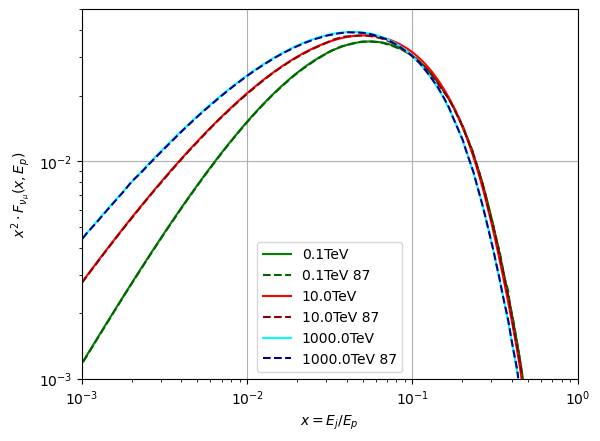

In [5]:
data01 = pd.read_csv('Figure9/DatasetFigure9-0.1TeV.csv',sep=';', header=None, names=['X','Y'])
data100 = pd.read_csv('Figure9/DatasetFigure9-100TeV.csv',sep=';', header=None, names=['X','Y'])
data1000 = pd.read_csv('Figure9/DatasetFigure9-1000TeV.csv',sep=';', header=None, names=['X','Y'])

tabdatanumu=[data01,data100,data1000]

Ep=[1e2,1e4,1e6]
Enumu01=np.linspace(Ep[0]*1e-3,Ep[0],100000)
Enumu100=np.linspace(Ep[1]*1e-3,Ep[1],100000)
Enumu1000=np.linspace(Ep[2]*1e-3,Ep[2],100000)

Enumu=[Enumu01,Enumu100,Enumu1000]

x=[]
for i in range(len(Ep)):
    x.append(Enumu[i]/Ep[i])




for i in range(len(tabdatanumu)):
    
    tabdatanumu[i].X=tabdatanumu[i].X.replace(',','.',regex=True)
    tabdatanumu[i].Y=tabdatanumu[i].Y.replace(',','.',regex=True)

X01=data01.X.astype('float64')
Y01=data01.Y.astype('float64')
X100=data100.X.astype('float64')
Y100=data100.Y.astype('float64')
X1000=data1000.X.astype('float64')
Y1000=data1000.Y.astype('float64')

x2Fnumu01=x[0]**2*(Fmu1(x[0],Ep[0])+Fe(x[0],Ep[0]))
x2Fnumu100=x[1]**2*(Fmu1(x[1],Ep[1])+Fe(x[1],Ep[1]))
x2Fnumu1000=x[2]**2*(Fmu1(x[2],Ep[2])+Fe(x[2],Ep[2]))

plt.xscale('log') ; plt.yscale('log')
plt.xlim(1e-3,1) ; plt.ylim(1e-3,5e-2)
plt.xlabel('$x=E_j/E_p$') ; plt.ylabel(r'$x^2 \cdot F_{\nu_\mu} (x,E_p)$')

plt.plot(x[0],x2Fnumu01,label=str(Ep[0]/1000) + "TeV",color='green')
plt.plot(X01,Y01,label=str(Ep[0]/1000) + "TeV 87",color='darkgreen',linestyle='--')

plt.plot(x[1],x2Fnumu100,label=str(Ep[1]/1000) + "TeV",color='red')
plt.plot(X100,Y100,label=str(Ep[1]/1000) + "TeV 87",color='darkred',linestyle='--')

plt.plot(x[2],x2Fnumu1000,label=str(Ep[2]/1000) + "TeV",color='cyan')
plt.plot(X1000,Y1000,label=str(Ep[2]/1000) + "TeV 87",color='darkblue',linestyle='--')

plt.grid()
plt.legend()



#Thus, in the paper, it's not 100TeV , it's 10 instead.

In [ ]:
data0003b = pd.read_csv('EGB-Figure11/EGB-Fig11-0.003-black.csv',sep=';', header=None, names=['X','Y'])
data0003r = pd.read_csv('EGB-Figure11/EGB-Fig11-0.003-red.csv',sep=';', header=None, names=['X','Y'])

data001b = pd.read_csv('EGB-Figure11/EGB-Fig11-0.01-black.csv',sep=';', header=None, names=['X','Y'])
data001r = pd.read_csv('EGB-Figure11/EGB-Fig11-0.01-red.csv',sep=';', header=None, names=['X','Y'])

data003b = pd.read_csv('EGB-Figure11/EGB-Fig11-0.03-black.csv',sep=';', header=None, names=['X','Y'])
data003r = pd.read_csv('EGB-Figure11/EGB-Fig11-0.03-red.csv',sep=';', header=None, names=['X','Y'])

data01b = pd.read_csv('EGB-Figure11/EGB-Fig11-0.1-black.csv',sep=';', header=None, names=['X','Y'])
data01r = pd.read_csv('EGB-Figure11/EGB-Fig11-0.1-red.csv',sep=';', header=None, names=['X','Y'])





tabdata=[data0003b,data0003r,data001b,data001r,data003b,data003r,data01b,data01r]

for i in range(len(tabdata)):
    
    tabdata[i].X=tabdata[i].X.replace(',','.',regex=True)
    tabdata[i].Y=tabdata[i].Y.replace(',','.',regex=True)

X0003b=data0003b.X.astype('float64')
Y0003b=data0003b.Y.astype('float64')

X0003r=data0003r.X.astype('float64')
Y0003r=data0003r.Y.astype('float64')

X001b=data001b.X.astype('float64')
Y001b=data001b.Y.astype('float64')

X001r=data001r.X.astype('float64')
Y001r=data001r.Y.astype('float64')

X003b=data003b.X.astype('float64')
Y003b=data003b.Y.astype('float64')

X003r=data003r.X.astype('float64')
Y003r=data003r.Y.astype('float64')

X01b=data01b.X.astype('float64')
Y01b=data01b.Y.astype('float64')

X01r=data01r.X.astype('float64')
Y01r=data01r.Y.astype('float64')

tabXb=[X0003b,X001b,X003b,X01b]
tabYb=[Y0003b,Y001b,Y003b,Y01b]
tabXr=[X0003r,X001r,X003r,X01r]
tabYr=[Y0003r,Y001r,Y003r,Y01r]

E_gamma=np.logspace(np.log10(1e1),np.log10(1e5),400)
tabz=[0.003, 0.01, 0.03, 0.1]
tabcolor=['darkslategray','teal','cadetblue','lightseagreen']
for i in range (len(tabz)) :
    if i==0 : 
        
        plt.plot(tabXb[i],tabYb[i],color='black',linewidth=0.8,linestyle='--',label='Franceschini & Rodighiero (2017)')
        plt.plot(tabXr[i],tabYr[i],color='red',linewidth=0.8,linestyle='--', label= 'Franceschini et al. (2008)')
        tauEGB=tau_gammagamma(E_gamma,tabz[i])
        plt.plot(E_gamma,tauEGB,linewidth=0.8,label= 'z = '+str(tabz[i]), color=tabcolor[i])
        

    else :
        
        plt.plot(tabXb[i],tabYb[i],color='black',linewidth=0.8,linestyle='--')
        plt.plot(tabXr[i],tabYr[i],color='red',linewidth=0.8,linestyle='--')
        tauEGB=tau_gammagamma(E_gamma,tabz[i])
        plt.plot(E_gamma,tauEGB,linewidth=0.8,label= 'z = '+str(tabz[i]), color=tabcolor[i])





plt.xscale('log') ; plt.yscale('log')
plt.xlim(6e1,1e5) ; plt.ylim(1e-2,3e2)
plt.xlabel('E$_\\gamma$ [GeV]') ; plt.ylabel('$\\tau$(E$_\\gamma$,z)')
plt.grid()
plt.legend()




dict_keys(['franceschini', 'dominguez', 'finke', 'franceschini17', 'saldana-lopez21'])
<class 'gammapy.modeling.models.spectral.EBLAbsorptionNormSpectralModel'>
a
[1.000e-03 2.000e-03 3.000e-03 ... 1.999e+00 2.000e+00 2.001e+00]
[2.0000004e+07 2.4045296e+07 2.8908806e+07 3.4756032e+07 4.1785940e+07
 5.0237744e+07 6.0399052e+07 7.2615632e+07 8.7303184e+07 1.0496150e+08
 1.2619153e+08 1.5171560e+08 1.8240224e+08 2.1929570e+08 2.6365138e+08
 3.1697872e+08 3.8109229e+08 4.5817370e+08 5.5084589e+08 6.6226240e+08
 7.9621453e+08 9.5726035e+08 1.1508800e+09 1.3836625e+09 1.6635282e+09
 2.0000004e+09 2.4045294e+09 2.8908805e+09 3.4756032e+09 4.1785933e+09
 5.0237737e+09 6.0399048e+09 7.2615629e+09 8.7303188e+09 1.0496150e+10
 1.2619147e+10 1.5171554e+10 1.8240223e+10 2.1929570e+10 2.6365137e+10
 3.1697867e+10 3.8109217e+10 4.5817356e+10 5.5084577e+10 6.6226229e+10
 7.9621448e+10 9.5726035e+10 1.1508801e+11 1.3836626e+11 1.6635281e+11] keV


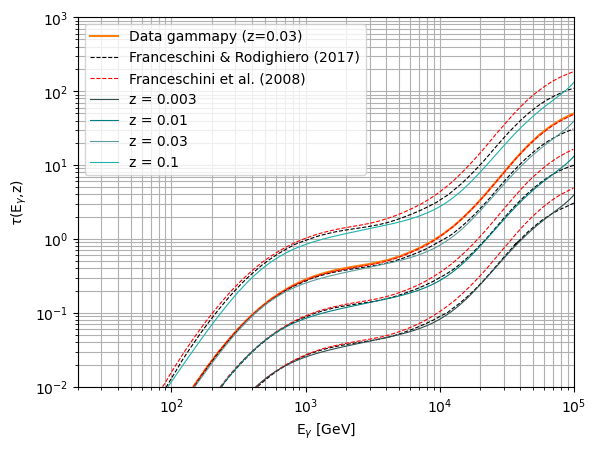

In [3]:
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
from gammapy.modeling.models import (
    EBL_DATA_BUILTIN,
    EBLAbsorptionNormSpectralModel,
    Models,
    PowerLawSpectralModel,
    SkyModel,
)

data0003b = pd.read_csv('EGB-Figure11/EGB-Fig11-0.003-black.csv',sep=';', header=None, names=['X','Y'])
data0003r = pd.read_csv('EGB-Figure11/EGB-Fig11-0.003-red.csv',sep=';', header=None, names=['X','Y'])

data001b = pd.read_csv('EGB-Figure11/EGB-Fig11-0.01-black.csv',sep=';', header=None, names=['X','Y'])
data001r = pd.read_csv('EGB-Figure11/EGB-Fig11-0.01-red.csv',sep=';', header=None, names=['X','Y'])

data003b = pd.read_csv('EGB-Figure11/EGB-Fig11-0.03-black.csv',sep=';', header=None, names=['X','Y'])
data003r = pd.read_csv('EGB-Figure11/EGB-Fig11-0.03-red.csv',sep=';', header=None, names=['X','Y'])

data01b = pd.read_csv('EGB-Figure11/EGB-Fig11-0.1-black.csv',sep=';', header=None, names=['X','Y'])
data01r = pd.read_csv('EGB-Figure11/EGB-Fig11-0.1-red.csv',sep=';', header=None, names=['X','Y'])





tabdata=[data0003b,data0003r,data001b,data001r,data003b,data003r,data01b,data01r]

for i in range(len(tabdata)):
    
    tabdata[i].X=tabdata[i].X.replace(',','.',regex=True)
    tabdata[i].Y=tabdata[i].Y.replace(',','.',regex=True)

X0003b=data0003b.X.astype('float64')
Y0003b=data0003b.Y.astype('float64')

X0003r=data0003r.X.astype('float64')
Y0003r=data0003r.Y.astype('float64')

X001b=data001b.X.astype('float64')
Y001b=data001b.Y.astype('float64')

X001r=data001r.X.astype('float64')
Y001r=data001r.Y.astype('float64')

X003b=data003b.X.astype('float64')
Y003b=data003b.Y.astype('float64')

X003r=data003r.X.astype('float64')
Y003r=data003r.Y.astype('float64')

X01b=data01b.X.astype('float64')
Y01b=data01b.Y.astype('float64')

X01r=data01r.X.astype('float64')
Y01r=data01r.Y.astype('float64')

tabXb=[X0003b,X001b,X003b,X01b]
tabYb=[Y0003b,Y001b,Y003b,Y01b]
tabXr=[X0003r,X001r,X003r,X01r]
tabYr=[Y0003r,Y001r,Y003r,Y01r]

E_gamma=np.logspace(np.log10(1e1),np.log10(1e5),400)
tabz=[0.003, 0.01, 0.03, 0.1]
tabcolor=['darkslategray','teal','cadetblue','lightseagreen']





#plt.vlines(x=15.2e3,ymin=1e-2,ymax=1e3,color="black",linestyles='dotted') #to verify which is which
#plt.hlines(y=6.14335,xmin=1e1,xmax=1e5,color="black",linestyles='dotted')
#plt.hlines(y=8.516,xmin=1e1,xmax=1e5,color="red",linestyles='dotted')
#plt.hlines(y=1.59762,xmin=1e1,xmax=1e5,color="black",linestyles='dotted')
#plt.hlines(y=2.048,xmin=1e1,xmax=1e5,color="red",linestyles='dotted')




# Print the available EBL models
print(EBL_DATA_BUILTIN.keys())
print(EBLAbsorptionNormSpectralModel)
# Here we illustrate how to create and plot EBL absorption models for a redshift of 0.5

redshift = 3e-2
franceschini = EBLAbsorptionNormSpectralModel.read("ebl_franceschini.fits.gz",redshift=redshift)
print("a")
print(franceschini.param)
print((franceschini.energy))
energy_bounds = [1e-3, 1e3] * u.TeV
opts = dict(energy_bounds=energy_bounds, xunits=u.TeV)

a=franceschini.plot(**opts,alpha=0)
plt.plot(1000*franceschini.energy,-np.log(franceschini.data[int(redshift*1000)-1]),label=f"Data gammapy (z={redshift})")


for i in range (len(tabz)) :
    if i==0 : 
        
        plt.plot(tabXb[i],tabYb[i],color='black',linewidth=0.8,linestyle='--',label='Franceschini & Rodighiero (2017)')
        plt.plot(tabXr[i],tabYr[i],color='red',linewidth=0.8,linestyle='--', label= 'Franceschini et al. (2008)')
        tauEGB=tau_gammagamma(E_gamma,tabz[i])
        plt.plot(E_gamma,tauEGB,linewidth=0.8,label= 'z = '+str(tabz[i]), color=tabcolor[i])
        

    else :
        
        plt.plot(tabXb[i],tabYb[i],color='black',linewidth=0.8,linestyle='--')
        plt.plot(tabXr[i],tabYr[i],color='red',linewidth=0.8,linestyle='--')
        tauEGB=tau_gammagamma(E_gamma,tabz[i])
        plt.plot(E_gamma,tauEGB,linewidth=0.8,label= 'z = '+str(tabz[i]), color=tabcolor[i])
plt.xlabel('E$_\\gamma$ [GeV]') ; plt.ylabel('$\\tau$(E$_\\gamma$,z)')
plt.xlim(2e1,1e5)
plt.ylim(1e-2, 1e3)
#plt.title(f"EBL models (z={redshift})")
plt.grid(which="both")
plt.legend(loc="best")


# The power-law model is multiplied by the EBL norm spectral model

plt.show()
